# Test MCTS

In [1]:
import cma

## Load data

In [2]:
# vessel data
vessels_pool = cma.read_vessel_class_data()

In Total  92  ports are plotted


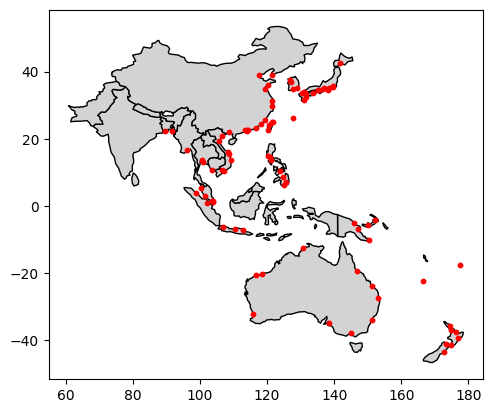

In [3]:
# port data
_, portpool = cma.read_port_data()

MAP_FILE_PATH = './110m_cultural/ne_110m_admin_0_countries.shp'
asia_pacific_countries = [
	'China','Taiwan', 'Japan', 'South Korea',
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore', 'Brunei', 'Timor-Leste',
	'Pakistan', 'India', 'Bangladesh', 'Sri Lanka', 'Nepal','Maldives',
	'Australia', 'Papua New Guinea', 'New Zealand', 'Solomon Islands',
	'Vanuatu', 'Samoa', 'Tonga', 'Tuvalu', 'Nauru', 'Palau', 'Marshall Islands','Kiribati' #, 'Fiji'
]
_, ax, portpool_selected = portpool.plot(MAP_FILE_PATH, asia_pacific_countries, plot_port_id = False)

In [4]:
# lines data
current_lines, _ = cma.read_current_line_data(portpool_selected)

In [5]:
# sailing distance data
dist_mat = cma.read_sailing_distance_data(portpool_selected)

c:\Users\nuscm\Documents\GitHub\nus_cma_project\src\cma\data_reader.py:122: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file_sail_distance)  # read first table


In [6]:
# demand data
demands_dict, total_weekly_demand_mat = cma.read_demand_data(portpool_selected)

## Create Root Service graph

In [7]:
portgraph = cma.PortGraph(portpool_selected, dist_mat, total_weekly_demand_mat)
servicegraph = cma.ServiceGraph(current_lines)

In [8]:
# calculate the cost of the current service network
# sol = servicegraph.solve_approximated_cost(portgraph, vessels_pool, False, trans_cost_req=75)

## Run MCTS

In [9]:
tree = cma.MonteCarloTree(
    service_graph=servicegraph, 
    portgraph=portgraph, 
    vesselpool=vessels_pool, 
    discount_fac=0.5, max_depth=5, c_param=0.5)

In [ ]:
tree.run(10)

c:\Users\nuscm\AppData\Local\Programs\Python\Python311\Lib\site-packages\cvxpy\problems\problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


                                     CVXPY                                     
                                     v1.6.3                                    
(CVXPY) Mar 13 05:01:40 PM: Your problem has 23299 variables, 25100 constraints, and 0 parameters.
(CVXPY) Mar 13 05:01:41 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 13 05:01:41 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 13 05:01:41 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 13 05:01:41 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 13 05:01:44 PM: Compiling problem (target solver=GLPK